#### **2. Logistic Regression: Preprocessing, Interpretation, and Evaluation**

In [12]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

# Four numeric features: 3 informative, 1 redundant (a linear combination of them)
X_num, y = make_classification(
    n_samples=600,
    n_features=4,
    n_informative=3,
    n_redundant=1,
    class_sep=0.9,         # how far apart the two class clusters sit
    weights=[0.68, 0.32],  # class imbalance: 68% negative, 32% positive
    flip_y=0.03,           # 3% of labels randomly flipped (label noise)
    random_state=21
)

df = pd.DataFrame(X_num, columns=["x1", "x2", "x3", "x4"])
rng = np.random.default_rng(21)
df["region"] = rng.choice(["north", "south", "east"], size=len(df))  # nominal, 3 levels
df["device"] = rng.choice(["mobile", "desktop"], size=len(df))       # nominal, 2 levels
df.loc[rng.choice(len(df), 25, replace=False), "x3"] = np.nan        # 25 missing values

In [13]:
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

# Figure output quality settings
plt.rcParams['figure.dpi']     = 120    # on-screen preview
plt.rcParams['savefig.dpi']    = 500    # saved PNG files
plt.rcParams['savefig.bbox']   = 'tight'
plt.rcParams['font.size']      = 11
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.25
plt.rcParams['grid.linewidth'] = 0.6


def save_fig(name):
    """Save the current figure to figures/<name>.png at 500 dpi."""
    plt.savefig(f'figures/{name}.png', bbox_inches='tight')

---
**Question 1**

Explain why passing string-valued columns directly to `LogisticRegression` throws a runtime error. Furthermore, explain why applying basic `LabelEncoder` mapping categories to integers $\{0, 1, 2\}$ introduces a spurious ordinal assumption that degrades model generalizability.

---


Logistic Regression cannot directly use string values such as `"north"`, `"south"`, `"east"`, `"mobile"`, or `"desktop"`. The model works with numerical values. It first calculates a linear score

$$
z = \mathbf{w}^T\mathbf{x} + b
$$

and then applies the sigmoid function

$$
p = \frac{1}{1+e^{-z}}
$$

Because of this, the input features need to be numerical. If string columns are given directly to `LogisticRegression`, scikit-learn tries to convert the values into numbers. Values such as `"north"` cannot be converted, so an error like the following can occur:

```python
ValueError: could not convert string to float: 'north'
```

Using `LabelEncoder` is also not a good solution for nominal categorical features. For example, suppose the `region` values are encoded as

```text
east  -> 0
north -> 1
south -> 2
```

Logistic Regression would then treat these values as numerical quantities. This creates an artificial ordering:

$$
\text{south} > \text{north} > \text{east}.
$$

It also assumes that the distance between `east` and `north` is the same as the distance between `north` and `south`.

There is no such relationship between these regions. They are nominal categories, so there is no natural order or numerical distance between them. This is known as a spurious ordinal assumption.

Because of this, the model could learn patterns based on the arbitrary numbers assigned by `LabelEncoder`. Also, changing the encoding, for example by assigning `east -> 2` instead of `east -> 0`, could change the model even though the original data has not changed.

---
**Question 2**

Construct a scikit-learn `Pipeline` combined with `ColumnTransformer` that:

- Imputes missing numerical entries with training set column medians;
- Standardizes numerical features ($\mu = 0, \sigma = 1$);
- Imputes missing categorical features using the most frequent mode;
- One-hot encodes categorical attributes; and
- Fits a Logistic Regression classifier.

Split the dataset into training (80%) and test (20%) subsets using a stratified split with `random_state=42`.

---


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ["x1", "x2", "x3", "x4"]     # numerical features
cat_cols = ["region", "device"]         # categorical features

X = df[num_cols + cat_cols]

# Stratified 80:20 split, so both sets keep the same class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

# Numerical: fill missing with the median, then standardize
num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

# Categorical: fill missing with the mode, then one-hot encode
cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Apply each sub-pipeline to its own set of columns
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

# Full pipeline: preprocessing + classifier
clf = Pipeline([
    ("pre", preprocessor),
    ("model", LogisticRegression(max_iter=1000)),
])

clf.fit(X_train, y_train)

print(f"Train size: {X_train.shape[0]}, test size: {X_test.shape[0]}")
print(f"Positive class share - train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")
print(f"Missing x3 values    - train: {X_train['x3'].isna().sum()}, "
      f"test: {X_test['x3'].isna().sum()}")

# Column names after one-hot encoding
print("\nFeatures after preprocessing:")
print(list(clf.named_steps["pre"].get_feature_names_out()))

print(f"\nTrain accuracy: {clf.score(X_train, y_train):.4f}")
print(f"Test accuracy : {clf.score(X_test, y_test):.4f}")

Train size: 480, test size: 120
Positive class share - train: 0.329, test: 0.325
Missing x3 values    - train: 22, test: 3

Features after preprocessing:
['num__x1', 'num__x2', 'num__x3', 'num__x4', 'cat__region_east', 'cat__region_north', 'cat__region_south', 'cat__device_desktop', 'cat__device_mobile']

Train accuracy: 0.8854
Test accuracy : 0.8500


---
**Question 3**

Perform a grid search over regularization strengths $C \in \{0.01, 0.1, 1, 10, 100\}$ and penalty types penalty $\in \{\ell_1, \ell_2\}$ using `solver='liblinear'` and 5-fold Stratified Cross-Validation. Optimize for $F_1$-score. Report best parameters and cross-validation score.

---


In [15]:
import warnings

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# sklearn 1.8+ deprecates penalty= in favour of l1_ratio, but Q3 asks for
# penalty in {l1, l2}, so keep penalty= and hide the deprecation notices
warnings.filterwarnings("ignore", message="'penalty' was deprecated")
warnings.filterwarnings("ignore", message="Inconsistent values: penalty")

# Same pipeline as Q2, but with liblinear so both l1 and l2 are supported
grid_clf = Pipeline([
    ("pre", preprocessor),
    ("model", LogisticRegression(solver="liblinear", max_iter=1000)),
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
}

# 5-fold stratified CV keeps the class balance in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = GridSearchCV(grid_clf, param_grid, cv=cv, scoring="f1")
search.fit(X_train, y_train)

best_model = search.best_estimator_    # refit on the full training set

print(f"Best parameters : C = {search.best_params_['model__C']}, "
      f"penalty = {search.best_params_['model__penalty']}")
print(f"Best CV F1-score: {search.best_score_:.4f}")

# Mean CV F1 for every combination in the grid
print(f"\n{'C':>8}{'l1':>10}{'l2':>10}")
results = search.cv_results_
for C in param_grid["model__C"]:
    scores = []
    for penalty in ("l1", "l2"):
        i = next(k for k, p in enumerate(results["params"])
                 if p["model__C"] == C and p["model__penalty"] == penalty)
        scores.append(results["mean_test_score"][i])
    print(f"{C:>8}{scores[0]:>10.4f}{scores[1]:>10.4f}")

Best parameters : C = 1, penalty = l1
Best CV F1-score: 0.8148

       C        l1        l2
    0.01    0.7418    0.7843
     0.1    0.8007    0.8033
       1    0.8148    0.8073
      10    0.7997    0.7997
     100    0.7997    0.7997


---
**Question 4**

On the test set, evaluate and report accuracy, precision, recall, $F_1$-score, and confusion matrix. Explain why overall accuracy can be deeply misleading when dealing with class-imbalanced datasets (e.g., 68% negative, 32% positive).

---


In [16]:
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             confusion_matrix, f1_score, precision_score,
                             recall_score)

# Predict with the best model found by the Q3 grid search
y_pred = best_model.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion matrix:\n{cm}")

tn, fp, fn, tp = cm.ravel()
print(f"\nTN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")

# Accuracy of a baseline that always predicts the majority (negative) class
baseline = 1 - y_test.mean()
print(f"\nMajority-class baseline accuracy: {baseline:.4f}")

Accuracy : 0.8583
Precision: 0.7895
Recall   : 0.7692
F1-score : 0.7792

Confusion matrix:
[[73  8]
 [ 9 30]]

TN = 73, FP = 8, FN = 9, TP = 30

Majority-class baseline accuracy: 0.6750


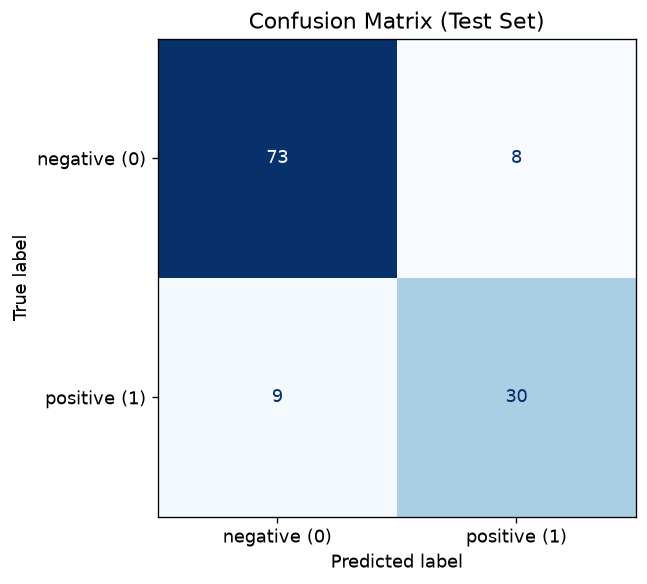

In [17]:
fig, ax = plt.subplots(figsize=(5.5, 5))

ConfusionMatrixDisplay(cm, display_labels=["negative (0)", "positive (1)"]).plot(
    ax=ax, cmap="Blues", colorbar=False)

ax.grid(False)      # the global grid setting would draw over the cells
ax.set_title("Confusion Matrix (Test Set)")

plt.tight_layout()
save_fig("q2_4_confusion_matrix")
plt.show()